# d50 Distance Metric Analysis

**What this notebook does:**
- Computes the inter-residue distance **d50** (distance between the tip Isoleucines of the flaps) from GROMACS distance CSV files for all available simulations
- Converts GROMACS distances from nm to Å (1 nm = 10 Å)
- Plots the distance trace for each simulation, split into **Phase 1** and **Phase 2**
  using per-simulation phase boundaries stored in `PHASE_LIMIT_DICO`
- Saves a zoomed view showing only Phase 2
- Computes and exports descriptive statistics to CSV

*Most up to date plots are here*

**Background:**
d50 measures the distance between ILE50 (chain A and B), residue index shifted by +99 → column `50_149` in the distance files.

**Sections:**
1. Install & import libraries
2. Configuration (paths, phase limits)
3. Helper function: `cal_d_50()`
4. Discover distance files
5. Plot all simulations (Phase 1 + Phase 2)
6. Plot zoomed view (Phase 2 only)
7. Compute and export statistics


In [1]:
# 1. Imports
import os
import math
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 2. Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 3. Configuration — adapt these paths to your environment
ROOTDIR    = '/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/'
OUTPUT_DIR = '/content/drive/MyDrive/M1_STAGE/Manips/'

os.chdir(ROOTDIR)

# Phase boundaries: frame index where Phase 1 ends and Phase 2 begins
PHASE_LIMIT_DICO = {
    'V7':  198,
    'V8':  180,
    'V21': 155,
    'V12': 35,
    'V11': 1000,
    'V1':  517,
}

title_font = {'fontsize': 14, 'fontweight': 'medium'}

In [4]:
# 4. Helper function — extract d50 from a distance DataFrame
def cal_d_50(distance_df: pd.DataFrame) -> pd.Series:
    """
    Return the d50 time series from a GROMACS distance file.
    Column '50-149' corresponds to the desired residue pair.
    """
    return distance_df['50-149']

In [5]:
# 5. Discover all distance files (files starting with 'distance_')
distance_files_paths = []
for subdir, _, files in os.walk(ROOTDIR):
    for f in files:
        if f.startswith('distance_'):
            distance_files_paths.append(os.path.join(subdir, f))

distance_files_paths.sort()
print(f'Found {len(distance_files_paths)} distance file(s):')
for p in distance_files_paths:
    print(' ', os.path.basename(p))

Found 6 distance file(s):
  distance_V1.csv
  distance_V11.csv
  distance_V12.csv
  distance_V21.csv
  distance_V7.csv
  distance_V8.csv


In [6]:
# 6. Extract d50 once and cache in a dictionary
d50_cache = {}

for distance_file in distance_files_paths:
    sim_name = os.path.basename(distance_file).replace('distance_', '').replace('.csv', '')
    df = pd.read_csv(distance_file) * 10  # nm → Å
    d50_cache[sim_name] = df['50_149']

print(f'Cached d50 data for {len(d50_cache)} simulations')

Cached d50 data for 6 simulations


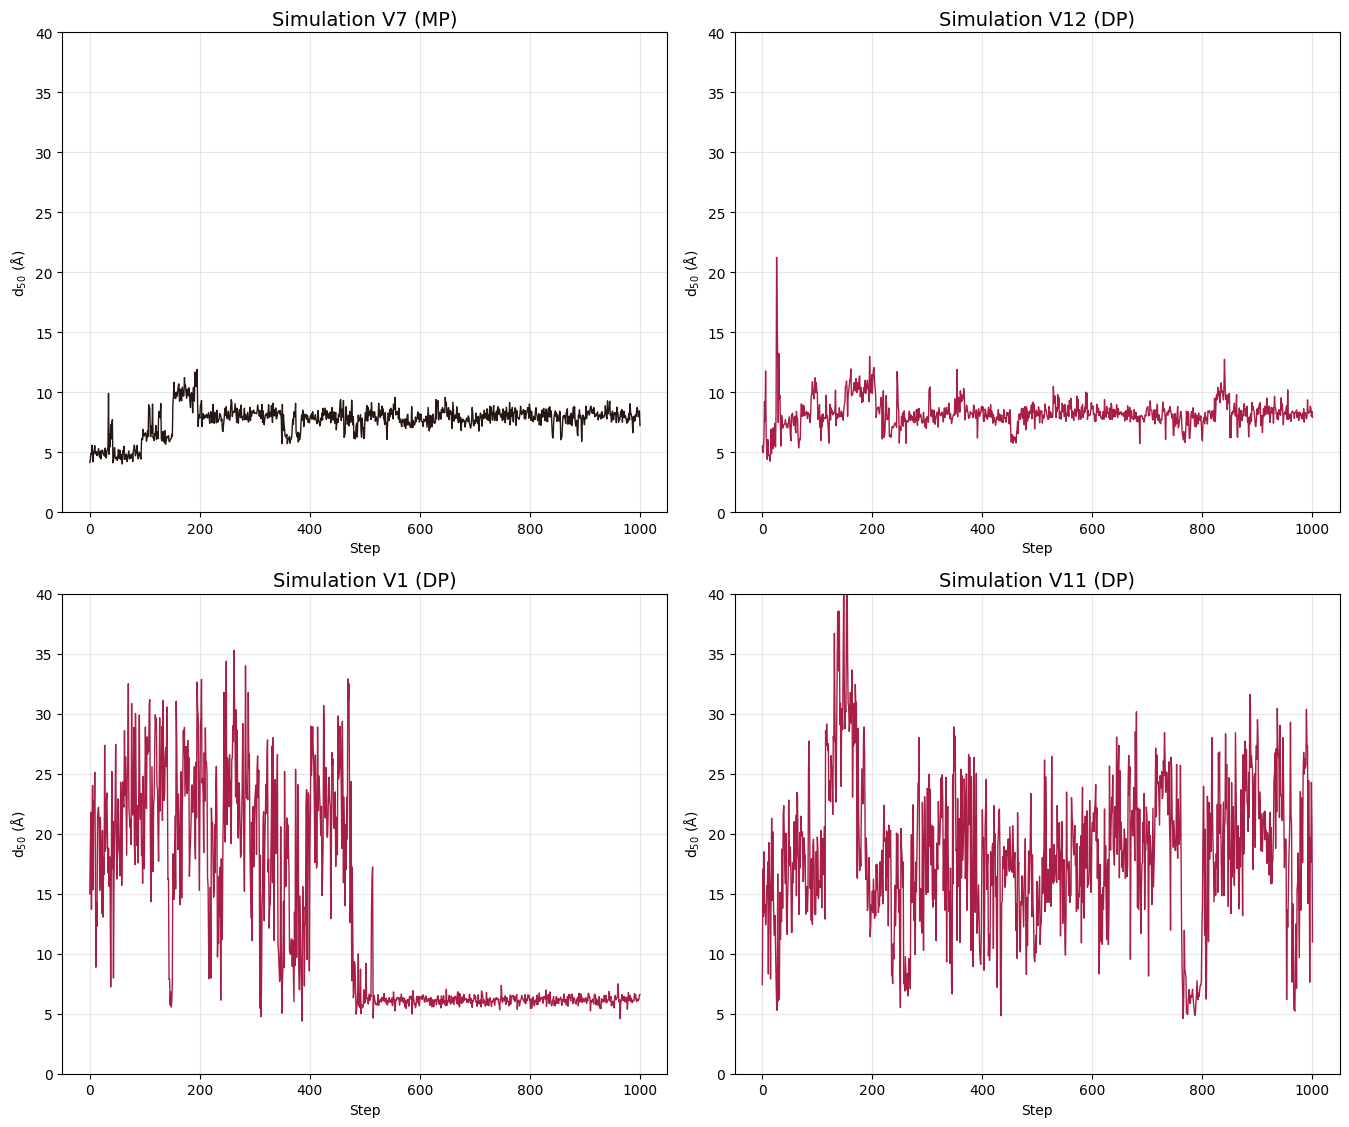

In [7]:
# 7. Plot d50 for all simulations — No phase separation
num_files = len(distance_files_paths)
num_cols  = 2
num_rows  = math.ceil(num_files / num_cols)

fig, axes = plt.subplots(num_rows, num_cols,
                          figsize=(num_cols * 8, num_rows * 6), squeeze=False)
axes = axes.flatten()
plot_idx = 0
line_mp = None
line_dp = None
#fig.suptitle(r'd$_{50}$ Analysis: MP vs DP', fontsize=22, x=0.45, y=0.92)

path_dict = {os.path.basename(f).replace('distance_', '').replace('.csv', ''): f for f in distance_files_paths}
sim_order = ['V7','V12','V1','V11']
files_sorted = []
for name in sim_order:
    if name in path_dict:
        files_sorted.append(path_dict[name])

for plot_idx, distance_file in enumerate(files_sorted):
    ax = axes[plot_idx]
    sim_name = os.path.basename(distance_file).replace('distance_', '').replace('.csv', '')

    plot_color = "#251714FF" if sim_name == 'V7' else '#A91E45FF'
    condition_label = "MP" if sim_name == 'V7' else 'DP'

    d_series = d50_cache[sim_name]

    current_line, = ax.plot(d_series.index[:], d_series[:], color=plot_color, linewidth=1)

    if sim_name == 'V7' or sim_name == 'V21' or sim_name == 'V8':
        line_mp = current_line
    elif line_dp is None:
        line_dp = current_line

    ax.set_title(f'Simulation {sim_name} ({condition_label})', fontdict=title_font)
    ax.set_xlabel('Step')
    ax.set_ylabel(r'd$_{50}$ (Å)')
    ax.set_ylim(0, 40)
    ax.grid(True, alpha=0.3)

# Hide unused axes
for j in range(plot_idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 0.85, 0.92])
plt.show()
#fig.savefig(os.path.join(OUTPUT_DIR, 'Figures/d_50.png'), bbox_inches='tight', dpi=300)

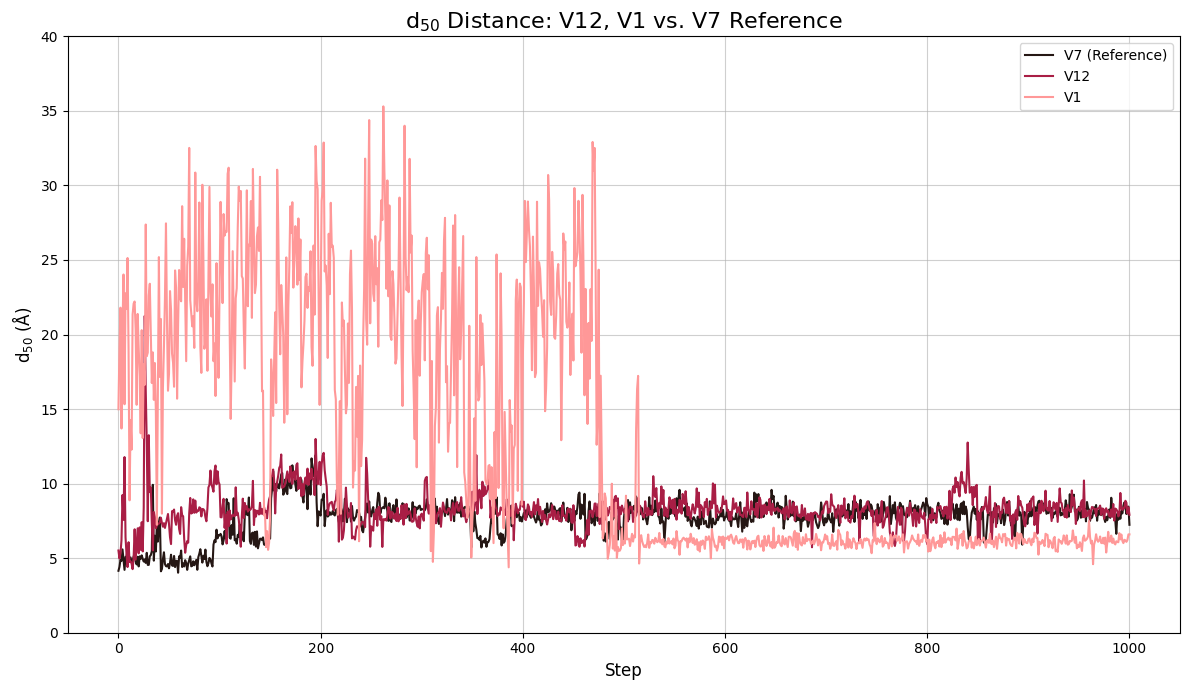

In [8]:
import matplotlib.pyplot as plt

# Create a single figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Simulations to plot
simulations_to_plot = ['V7', 'V12', 'V1']

# Define colors and labels for clarity
colors = {
    'V7': '#251714FF',  # Reference simulation
    'V12': '#A91E45FF',
    'V1': '#FF9898FF'
}

labels = {
    'V7': 'V7 (Reference)',
    'V12': 'V12',
    'V1': 'V1'
}

# Plot each simulation
for sim_name in simulations_to_plot:
    if sim_name in d50_cache:
        d_series = d50_cache[sim_name]
        ax.plot(d_series.index, d_series, color=colors[sim_name], label=labels[sim_name], linewidth=1.5)
    else:
        print(f"Warning: Simulation {sim_name} not found in cache.")

# Set plot title and labels
ax.set_title(r'd$_{50}$ Distance: V12, V1 vs. V7 Reference', fontsize=16)
ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel(r'd$_{50}$ (Å)', fontsize=12)

# Set y-axis limits for better visualization, consistent with previous plots
ax.set_ylim(0, 40)

# Add legend and grid
ax.legend(fontsize=10)
ax.grid(True, alpha=0.6)

plt.tight_layout()
plt.show()

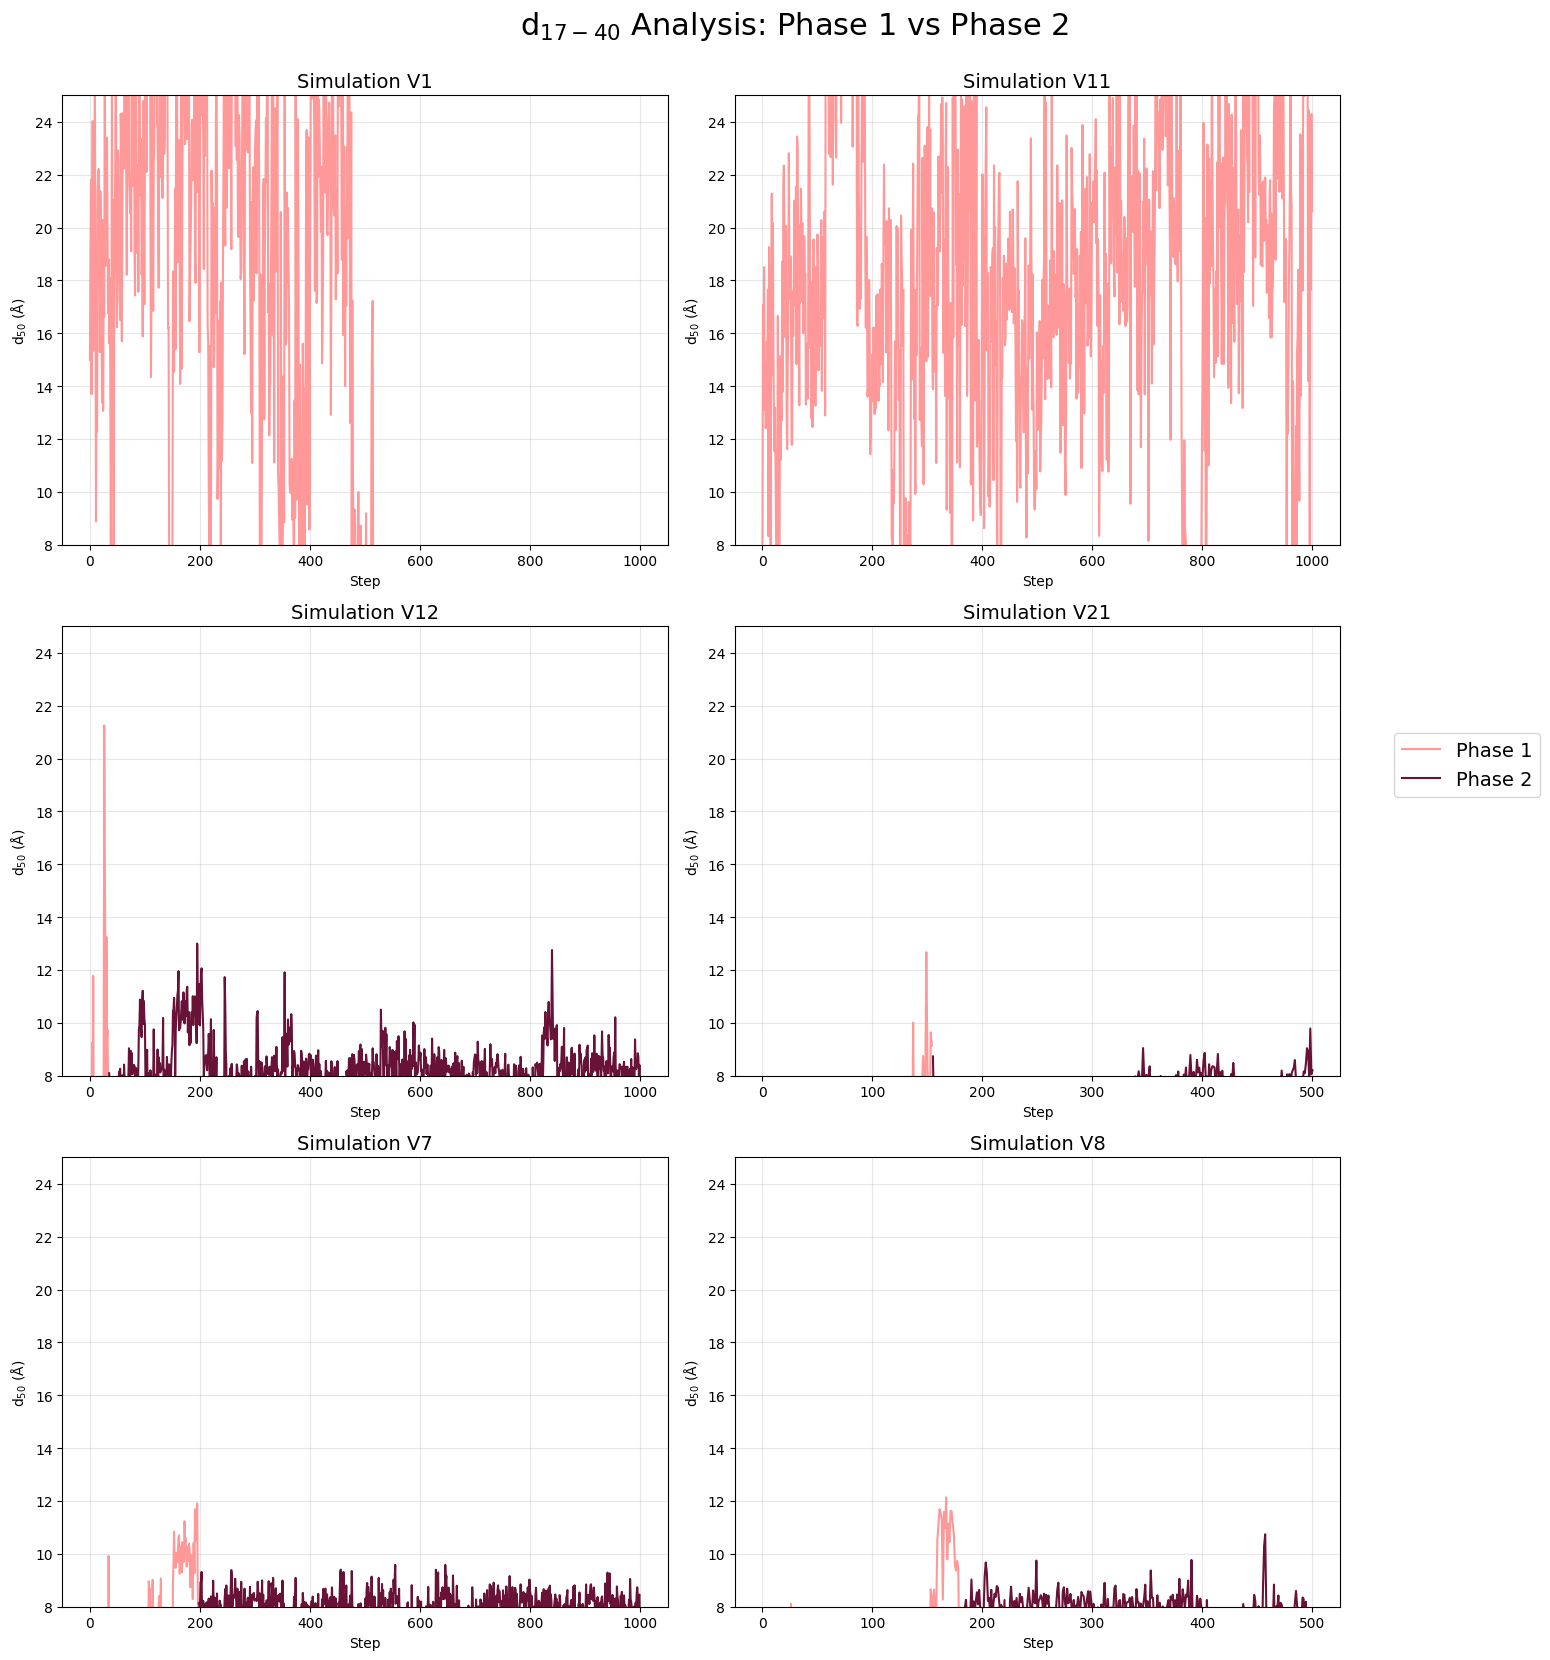

In [9]:
# 5. Plot d17-40 for all simulations — Phase 1 (pink) vs Phase 2 (cyan)
num_files = len(distance_files_paths)
num_cols  = 2
num_rows  = math.ceil(num_files / num_cols)

fig, axes = plt.subplots(num_rows, num_cols,
                          figsize=(num_cols * 8, num_rows * 6), squeeze=False)
axes = axes.flatten()
fig.suptitle(r'd$_{17-40}$ Analysis: Phase 1 vs Phase 2', fontsize=22, y=0.92)
line_ph1 =  None
line_ph2 = None

for plot_idx, distance_file in enumerate(distance_files_paths):
    ax = axes[plot_idx]
    sim_name = os.path.basename(distance_file).replace('distance_', '').replace('.csv', '')

    d_series = d50_cache[sim_name]
    phase_limit = PHASE_LIMIT_DICO.get(sim_name, len(d_series))

    line_ph1, = ax.plot(d_series.index[:phase_limit],  d_series[:phase_limit],
                        color='#FF9898FF', linewidth=1.5)
    line_ph2, = ax.plot(d_series.index[phase_limit:],  d_series[phase_limit:],
                        color='#691238FF', linewidth=1.5)
    ax.set_title(f'Simulation {sim_name}', fontdict=title_font)
    ax.set_xlabel('Step')
    ax.set_ylabel(r'd$_{50}$ (Å)')
    ax.set_ylim(8, 25)
    ax.grid(True, alpha=0.3)

# Hide unused axes
for j in range(plot_idx + 1, len(axes)):
    fig.delaxes(axes[j])

if line_ph1 and line_ph2:
    fig.legend(handles=[line_ph1, line_ph2], labels=['Phase 1', 'Phase 2'],
            loc='center', bbox_to_anchor=(0.92, 0.5),
            fontsize=14, frameon=True)

plt.tight_layout(rect=[0, 0, 0.85, 0.92])
plt.show()
fig.savefig(os.path.join(OUTPUT_DIR, 'Figures/d_50_phase_sep.png'), bbox_inches='tight', dpi=300)

IndexError: index 3 is out of bounds for axis 0 with size 3

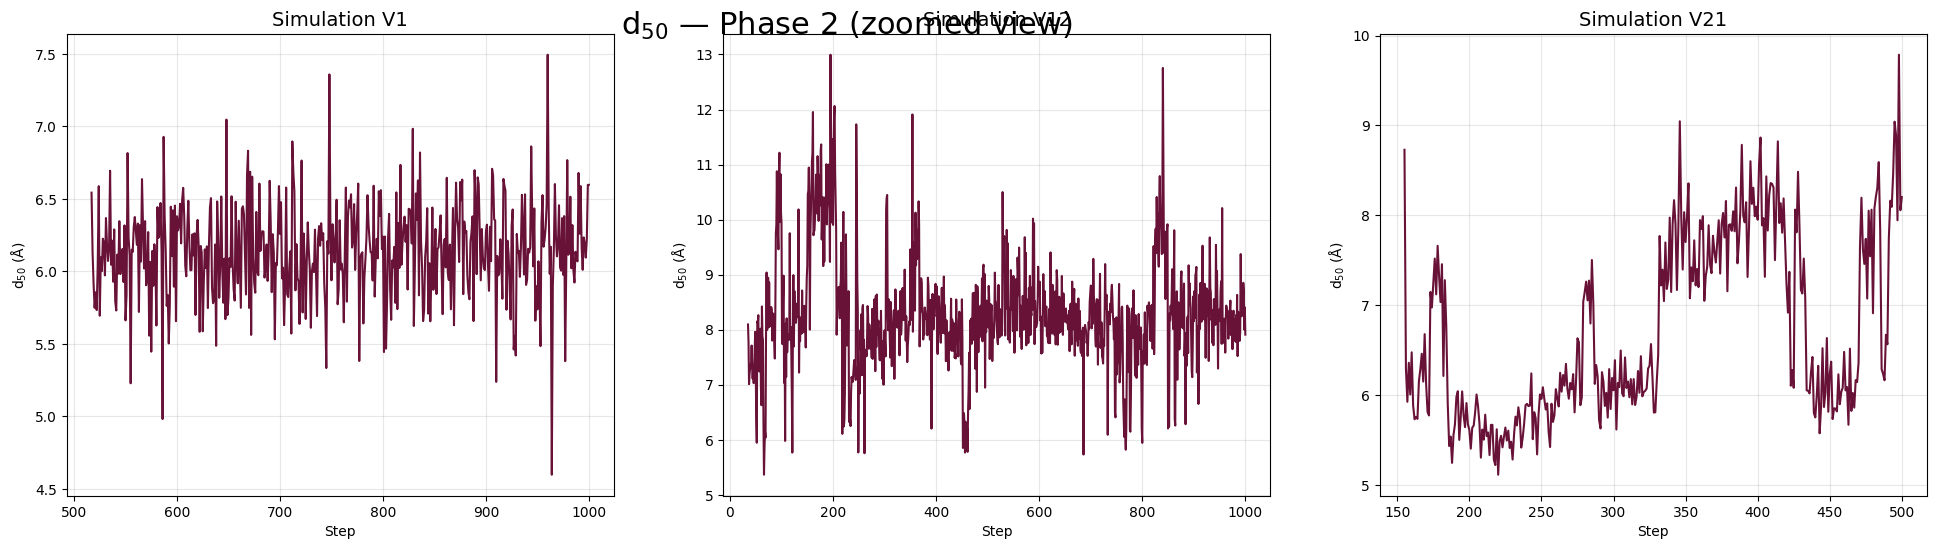

In [10]:
# 7. Zoomed plot — Phase 2 only
num_rows = 1
num_cols = 3

distance_files_paths = [path for path in distance_files_paths if not path.endswith('V11.csv')]

fig, axes = plt.subplots(num_rows, num_cols,
                          figsize=(num_cols * 8, num_rows * 6), squeeze=False)
axes = axes.flatten()
fig.suptitle(r'd$_{50}$ — Phase 2 (zoomed view)', fontsize=22, y=0.92, x=0.45)

for plot_idx, distance_file in enumerate(distance_files_paths):
    ax = axes[plot_idx]
    sim_name = os.path.basename(distance_file).replace('distance_', '').replace('.csv', '')

    d_series = d50_cache[sim_name]
    phase_limit = PHASE_LIMIT_DICO.get(sim_name, len(d_series))

    ax.plot(d_series.index[phase_limit:], d_series[phase_limit:],
            color='#691238FF', linewidth=1.5)
    ax.set_title(f'Simulation {sim_name}',fontdict=title_font)
    ax.set_xlabel('Step')
    ax.set_ylabel(r'd$_{50}$ (Å)')
    ax.grid(True, alpha=0.3)

for j in range(plot_idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 0.85, 0.92])
plt.show()
fig.savefig(os.path.join(OUTPUT_DIR, 'Figures/d_50_zoomed.png'), bbox_inches='tight', dpi=300)

In [ ]:
# 7. Descriptive statistics per simulation — exported to CSV
summary_stats_dict = {}

for distance_file in distance_files_paths:
    sim_name = os.path.basename(distance_file).replace('distance_', '').replace('.csv', '')
    df = pd.read_csv(distance_file) * 10
    df.index.name = 'step'
    d_series = cal_d_50(df)
    summary_stats_dict[sim_name] = d_series.describe()

summary_stats_df = pd.DataFrame(summary_stats_dict)
summary_stats_df.to_csv(
    os.path.join(OUTPUT_DIR, 'Tables/d_50_stats.csv'),
    index=True, header=True, decimal='.', float_format='%.3f'
)
summary_stats_df